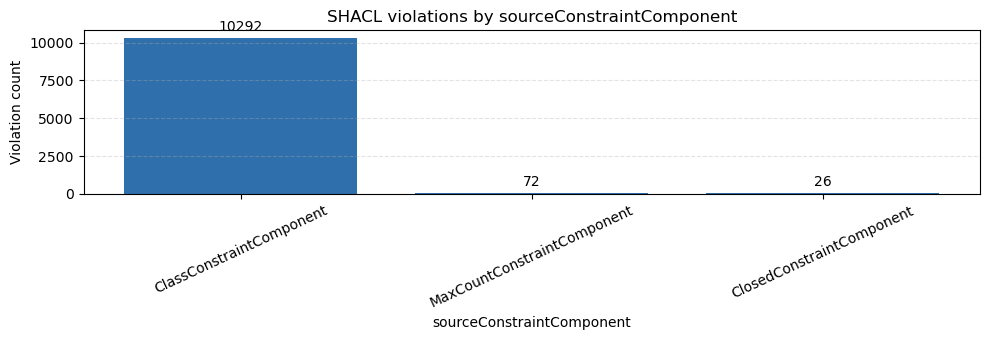

In [4]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt

workspace_root = Path.cwd().parent.parent
sys.path.insert(0, str(workspace_root))

import experiments.plots.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
component_counts = shacl_violation_distribution.collect_source_constraint_component_counts(str(run_directory))

if not component_counts:
    print("No SHACL violations found.")
else:
    ordered_items = component_counts.most_common()
    labels = [label for label, _ in ordered_items]
    values = [value for _, value in ordered_items]

    fig, ax = plt.subplots(figsize=(10, max(3.5, 0.5 * len(labels))))
    bars = ax.bar(labels, values, color="#2f6fab")
    ax.set_title("SHACL violations by sourceConstraintComponent")
    ax.set_xlabel("sourceConstraintComponent")
    ax.set_ylabel("Violation count")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{int(height)}",
            (bar.get_x() + bar.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=10,
            xytext=(0, 3),
            textcoords="offset points",
        )

    plt.tight_layout()
    plt.show()

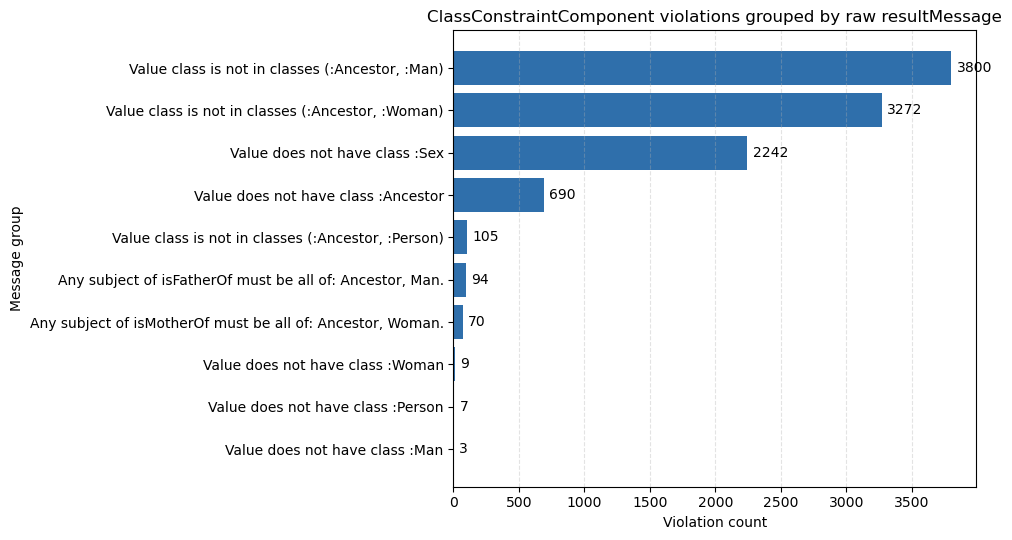

In [5]:
from pathlib import Path
import importlib
import sys
from textwrap import shorten

import matplotlib.pyplot as plt

workspace_root = Path.cwd().parent.parent
sys.path.insert(0, str(workspace_root))

import experiments.plots.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
message_counts = shacl_violation_distribution.collect_class_constraint_messages(str(run_directory))

if not message_counts:
    print("No ClassConstraintComponent violations found.")
else:
    ordered_items = message_counts.most_common()
    labels = [shorten(label, width=90, placeholder="...") for label, _ in ordered_items]
    values = [value for _, value in ordered_items]

    fig, ax = plt.subplots(figsize=(10, max(3.5, 0.55 * len(labels))))
    bars = ax.barh(labels, values, color="#2f6fab")
    ax.set_title("ClassConstraintComponent violations grouped by raw resultMessage")
    ax.set_xlabel("Violation count")
    ax.set_ylabel("Message group")
    ax.invert_yaxis()
    ax.grid(axis="x", linestyle="--", alpha=0.35)

    for bar in bars:
        width = bar.get_width()
        ax.annotate(
            f"{int(width)}",
            (width, bar.get_y() + bar.get_height() / 2),
            ha="left",
            va="center",
            fontsize=10,
            xytext=(4, 0),
            textcoords="offset points",
        )

    plt.tight_layout()
    plt.show()

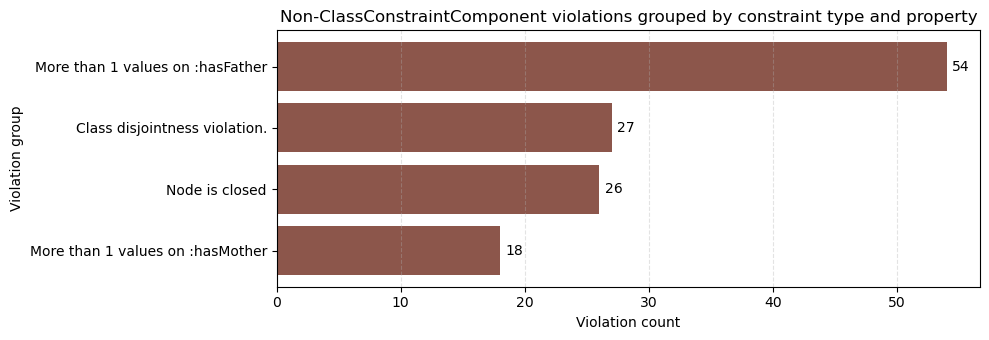

In [6]:
from pathlib import Path
import importlib
import sys
from textwrap import shorten

import matplotlib.pyplot as plt

workspace_root = Path.cwd().parent.parent
sys.path.insert(0, str(workspace_root))

import experiments.plots.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
other_message_counts = shacl_violation_distribution.collect_non_class_constraint_messages(str(run_directory))
reorganized_counts = shacl_violation_distribution.reorganize_non_class_violations(other_message_counts)

if not reorganized_counts:
    print("No non-ClassConstraintComponent violations found.")
else:
    ordered_items = reorganized_counts.most_common()
    labels = [shorten(label, width=90, placeholder="...") for label, _ in ordered_items]
    values = [value for _, value in ordered_items]

    fig, ax = plt.subplots(figsize=(10, max(3.5, 0.55 * len(labels))))
    bars = ax.barh(labels, values, color="#8c564b")
    ax.set_title("Non-ClassConstraintComponent violations grouped by constraint type and property")
    ax.set_xlabel("Violation count")
    ax.set_ylabel("Violation group")
    ax.invert_yaxis()
    ax.grid(axis="x", linestyle="--", alpha=0.35)

    for bar in bars:
        width = bar.get_width()
        ax.annotate(
            f"{int(width)}",
            (width, bar.get_y() + bar.get_height() / 2),
            ha="left",
            va="center",
            fontsize=10,
            xytext=(4, 0),
            textcoords="offset points",
        )

    plt.tight_layout()
    plt.show()

In [7]:
from pathlib import Path
import importlib
import sys

workspace_root = Path.cwd().parent.parent
sys.path.insert(0, str(workspace_root))

import experiments.plots.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
violations_by_message = shacl_violation_distribution.collect_non_class_violations_by_task(str(run_directory))

# Filter for class disjointness violations (case-insensitive search)
class_disjointness_tasks = set()
for message, tasks in violations_by_message.items():
    if "disjoint" in message.lower():
        class_disjointness_tasks.update(tasks)

# Filter for max count violations
max_count_tasks = set()
for message, tasks in violations_by_message.items():
    if "More than" in message:
        max_count_tasks.update(tasks)

print(f"Number of different tasks with class disjointness violations: {len(class_disjointness_tasks)}")
print(f"Number of different tasks with max count violations: {len(max_count_tasks)}")

Number of different tasks with class disjointness violations: 3
Number of different tasks with max count violations: 19


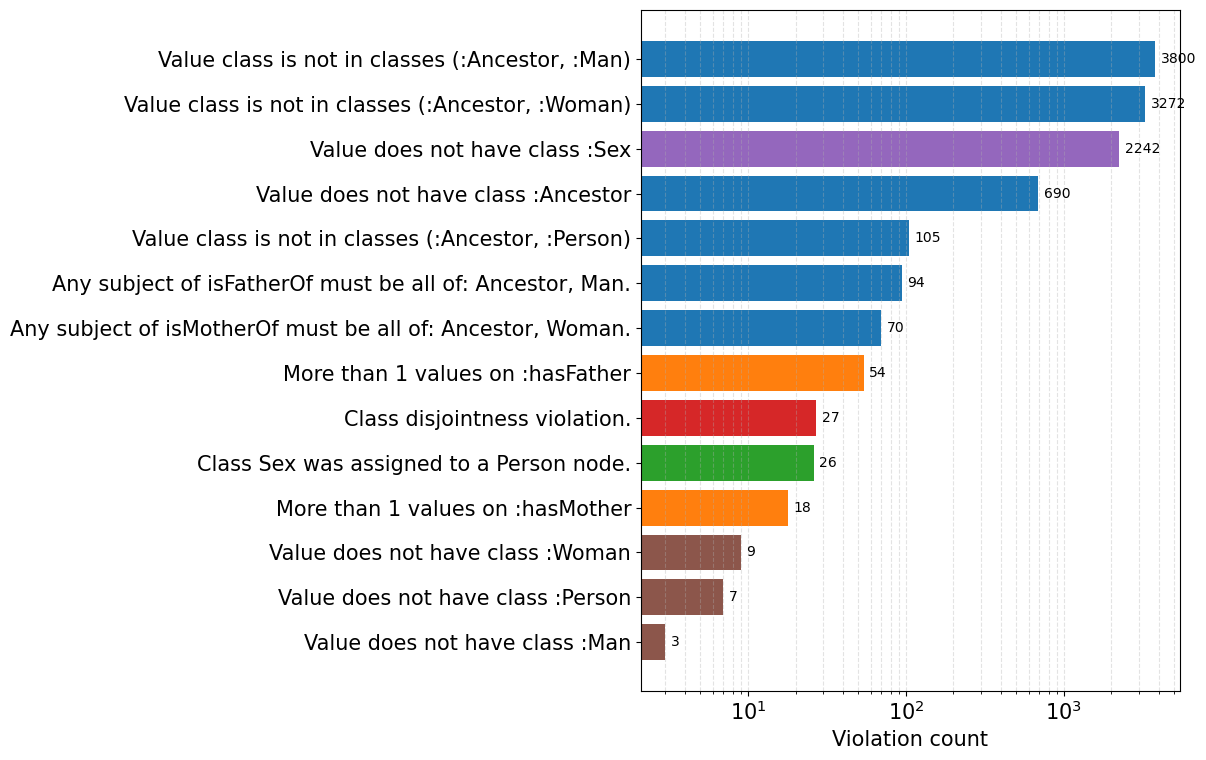

In [1]:
from pathlib import Path
import importlib
import sys
from collections import Counter
from textwrap import shorten

import matplotlib.pyplot as plt

workspace_root = Path.cwd().parent.parent
sys.path.insert(0, str(workspace_root))

import experiments.plots.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
class_message_counts = shacl_violation_distribution.collect_class_constraint_messages(str(run_directory))
non_class_message_counts = shacl_violation_distribution.collect_non_class_constraint_messages(str(run_directory))
reorganized_non_class_counts = shacl_violation_distribution.reorganize_non_class_violations(non_class_message_counts)
combined_message_counts = Counter(class_message_counts) + Counter(reorganized_non_class_counts)

if not combined_message_counts:
    print("No SHACL violations found.")
else:
    ordered_items = combined_message_counts.most_common()
    label_overrides = {
        "Node is closed": "Class Sex was assigned to a Person node.",
    }
    labels = [shorten(label_overrides.get(label, label), width=90, placeholder="...") for label, _ in ordered_items]
    values = [value for _, value in ordered_items]

    ancestor_bar_positions = {1, 2, 4, 5, 6, 7}
    more_than_bar_positions = {8, 11}
    distinct_bar_colors = {
        3: "#9467bd",
        9: "#d62728",
        10: "#2ca02c",
        12: "#8c564b",
        13: "#8c564b",
        14: "#8c564b",
    }
    ancestor_color = "#1f77b4"
    more_than_color = "#ff7f0e"
    bar_colors = []

    for index, label in enumerate(labels, start=1):
        if index in ancestor_bar_positions:
            bar_colors.append(ancestor_color)
        elif index in more_than_bar_positions:
            bar_colors.append(more_than_color)
        else:
            bar_colors.append(distinct_bar_colors.get(index, "#7f7f7f"))

    fig, ax = plt.subplots(figsize=(12, max(4.0, 0.55 * len(labels))))
    bars = ax.barh(labels, values, color=bar_colors)
    ax.set_xlabel("Violation count", fontsize=15)
    ax.set_xscale("log")
    ax.invert_yaxis()
    ax.grid(axis="x", linestyle="--", alpha=0.35, which="both")
    ax.tick_params(axis="both", labelsize=15)

    for bar in bars:
        width = bar.get_width()
        ax.annotate(
            f"{int(width)}",
            (width, bar.get_y() + bar.get_height() / 2),
            ha="left",
            va="center",
            fontsize=10,
            xytext=(4, 0),
            textcoords="offset points",
        )

    output_pdf = workspace_root / "results" / "royalty_gemini_with_shacl" / "combined_message_groups.pdf"
    fig.savefig(output_pdf, format="pdf", bbox_inches="tight")
    plt.tight_layout()
    plt.show()

In [ ]:
from collections import Counter
from pathlib import Path
import importlib
import json
import sys

from rdflib import Graph, SH, RDF

workspace_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(workspace_root))

import experiments.plots.shacl_violation_distribution as shacl_violation_distribution

shacl_violation_distribution = importlib.reload(shacl_violation_distribution)

run_directory = workspace_root / "results" / "royalty_gemini_with_shacl"
closed_violations = Counter()

for graphs_path in sorted(run_directory.rglob("artifacts/graphs.json")):
    try:
        records = json.loads(graphs_path.read_text(encoding="utf-8"))
    except (OSError, json.JSONDecodeError):
        continue

    if not isinstance(records, list):
        continue

    for record in records:
        if not isinstance(record, dict):
            continue

        if record.get("graph_type") != "validation_graph":
            continue

        graph_text = record.get("graph")
        if not isinstance(graph_text, str):
            continue

        try:
            graph = Graph()
            graph.parse(data=graph_text, format="turtle")
        except Exception:
            continue

        for result_node in graph.subjects(RDF.type, SH.ValidationResult):
            message = graph.value(result_node, SH.resultMessage)
            path = graph.value(result_node, SH.resultPath)
            component = graph.value(result_node, SH.sourceConstraintComponent)

            if component != SH.ClosedConstraintComponent:
                continue

            if message is None:
                continue

            closed_violations[(str(message), str(path) if path is not None else "(no path)")] += 1

if not closed_violations:
    print("No Node is closed violations found.")
else:
    print("Node is closed violations with path component:")
    for (message, path), count in closed_violations.most_common():
        print(f"- {count}x {message} | path: {path}")
    print(f"Total combined into Node is closed: {sum(closed_violations.values())}")

Node is closed violations with path component:
- 4x Node data:Ernest_Augustus_Crown_Prince_of_Hanover is closed. It cannot have value: data:George_V_of_Hanover | path: http://example.com/family_TBOX.ttl#hasFather
- 4x Node data:Prince_Ernest_Augustus_Duke_of_Cumberland_and_Teviotdale is closed. It cannot have value: data:George_III_of_the_United_Kingdom | path: http://example.com/family_TBOX.ttl#hasFather
- 2x Node data:Prince_Ernest_Augustus_II is closed. It cannot have value: data:Ernest_Augustus_Crown_Prince_of_Hanover | path: http://example.com/family_TBOX.ttl#hasFather
- 2x Node data:Prince_Ernest_Augustus_II is closed. It cannot have value: data:Princess_Victoria_Louise_of_Prussia | path: http://example.com/family_TBOX.ttl#hasRelation
- 2x Node data:George_William is closed. It cannot have value: data:Ernest_Augustus_Crown_Prince_of_Hanover | path: http://example.com/family_TBOX.ttl#hasFather
- 2x Node data:George_William is closed. It cannot have value: data:Princess_Thyra_of_De